In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import standard_3d_autoencoder as ae3d
from tqdm import tqdm

# Load model and data
device = ae3d.get_device()
_, test_loader = ae3d.get_mnist_loaders(64, 64)
model = ae3d.StandardAutoEncoder(3)

# Load the saved model (handle nested structure)
checkpoint = torch.load('autoencoder_3d.pth', map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()
print(f"Device: {device}")
print("Model loaded successfully")

Device: mps
Model loaded successfully


/var/folders/ll/7kn2qpx13h3d33v8br6bk2gw0000gp/T/ipykernel_1407/4100161872.py:181: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


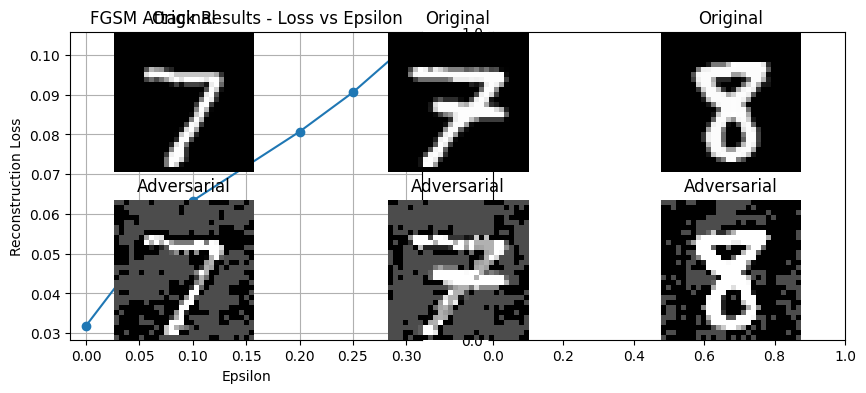

In [8]:
# FGSM Attack
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
fgsm_results = run_fgsm_attack(model, test_loader, epsilons, device)
plot_attack_results(fgsm_results, "FGSM Attack Results")

/var/folders/ll/7kn2qpx13h3d33v8br6bk2gw0000gp/T/ipykernel_1407/4100161872.py:181: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


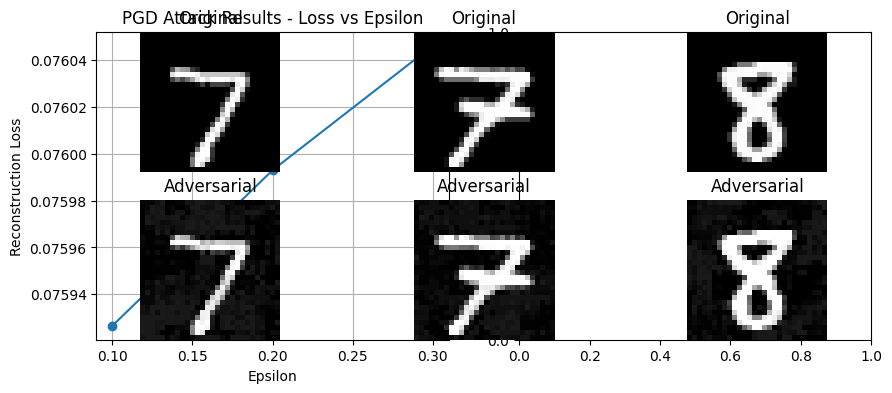

In [9]:
# PGD Attack
pgd_epsilons = [0.1, 0.2, 0.3]
pgd_results = run_pgd_attack(model, test_loader, pgd_epsilons, device)
plot_attack_results(pgd_results, "PGD Attack Results")

C&W Attack Results - Average Loss: 0.0310


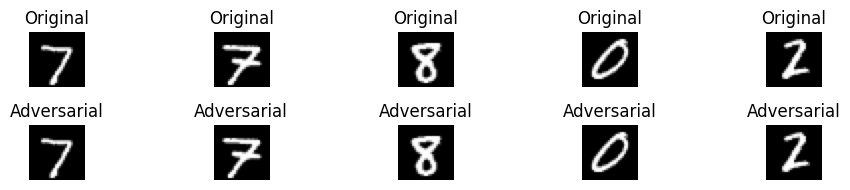

In [10]:
# C&W Attack
cw_results = run_cw_attack(model, test_loader, device)
plot_attack_results(cw_results, "C&W Attack Results")

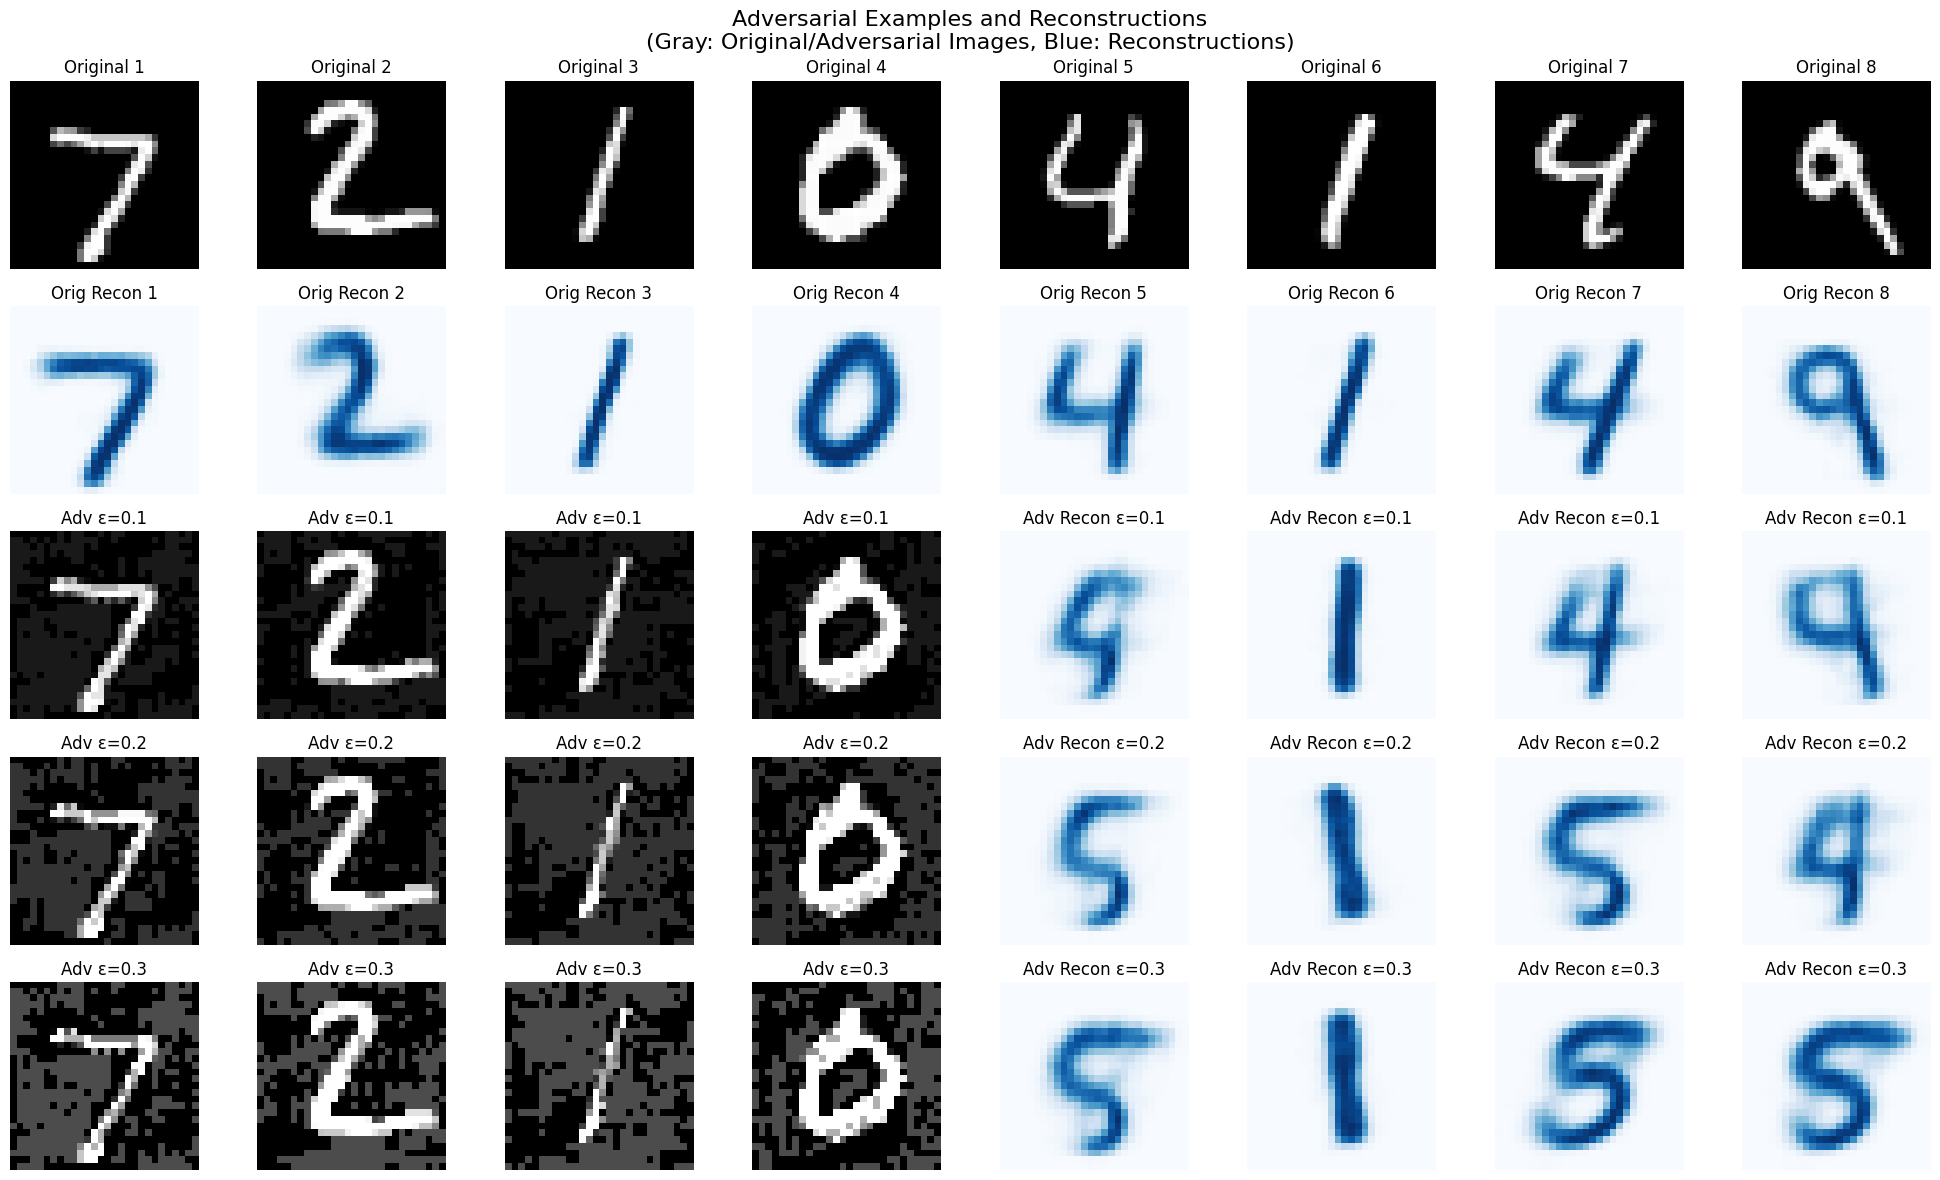

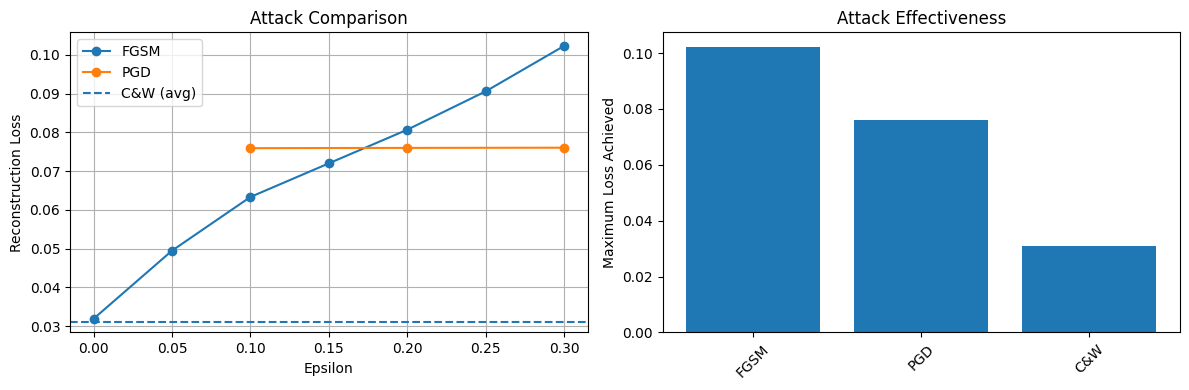

In [14]:
# Visualize adversarial examples (first batch)
visualize_adversarial_examples(model, test_loader, device, random_selection=False)

# Visualize adversarial examples (random selection)
# visualize_adversarial_examples(model, test_loader, device, random_selection=True)

# Compare all attacks
compare_all_attacks([fgsm_results, pgd_results, cw_results], 
                   ["FGSM", "PGD", "C&W"])

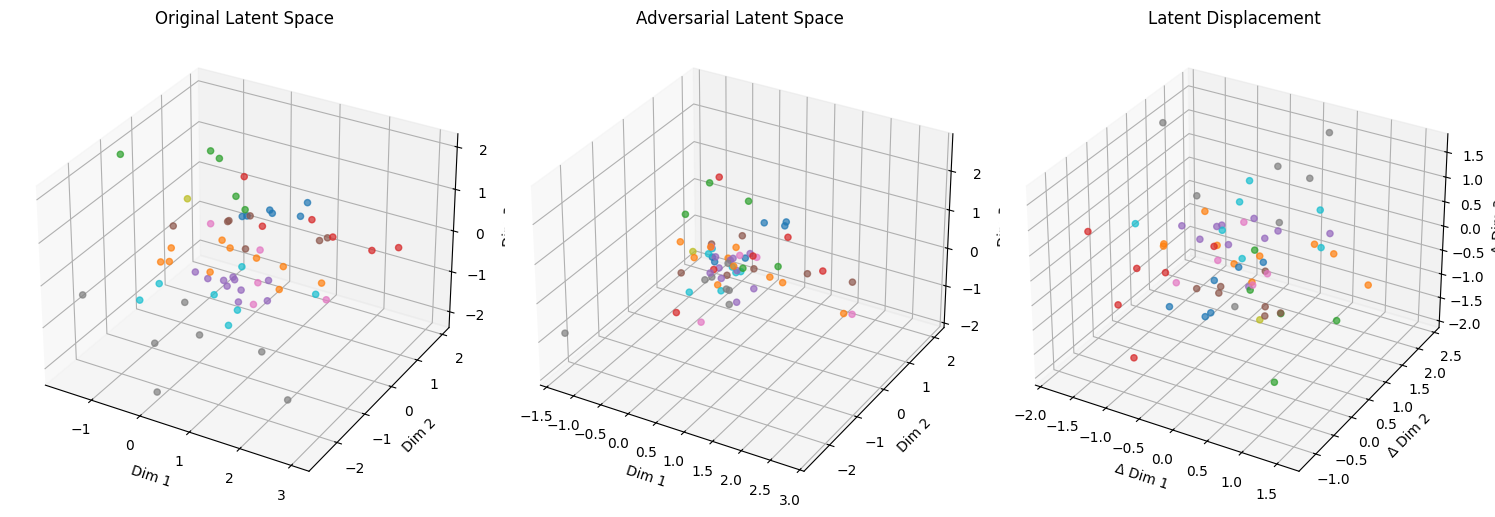

Average latent displacement: 1.2487
Max latent displacement: 2.8209
Min latent displacement: 0.1989


In [12]:
# Analyze latent space under attack
analyze_latent_space_attacks(model, test_loader, device)

In [ ]:
# ============= ATTACK FUNCTIONS =============

def fgsm_attack(image, epsilon, data_grad):
    """Fast Gradient Sign Method attack"""
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

def pgd_attack(model, image, epsilon, alpha=0.01, num_iter=10):
    """Projected Gradient Descent attack"""
    perturbed_image = image.clone().detach()
    
    for _ in range(num_iter):
        perturbed_image.requires_grad_()
        recon, mu, logvar, z = model(perturbed_image)
        loss = F.mse_loss(recon, perturbed_image)
        
        model.zero_grad()
        loss.backward()
        
        # Update perturbation
        data_grad = perturbed_image.grad.data
        perturbed_image = perturbed_image + alpha * data_grad.sign()
        
        # Project back to epsilon ball
        eta = torch.clamp(perturbed_image - image, min=-epsilon, max=epsilon)
        perturbed_image = torch.clamp(image + eta, 0, 1).detach_()
    
    return perturbed_image

def cw_attack(model, image, c=1.0, kappa=0, max_iter=1000, lr=0.01):
    """Carlini & Wagner attack"""
    def atanh(x):
        return 0.5 * torch.log((1 + x) / (1 - x))
    
    w = atanh((image * 2 - 1) * 0.999999).detach()
    w.requires_grad_()
    
    optimizer = torch.optim.Adam([w], lr=lr)
    
    for _ in range(max_iter):
        optimizer.zero_grad()
        
        # Convert to valid image
        adv_image = (torch.tanh(w) + 1) / 2
        
        # Reconstruction loss
        recon, mu, logvar, z = model(adv_image)
        recon_loss = F.mse_loss(recon, adv_image)
        
        # Perturbation loss
        l2_loss = torch.norm(adv_image - image)
        
        # Total loss
        loss = recon_loss + c * l2_loss
        
        loss.backward()
        optimizer.step()
        
        if _ % 100 == 0 and l2_loss < 0.1:
            break
    
    return (torch.tanh(w) + 1) / 2

def run_fgsm_attack(model, test_loader, epsilons, device):
    """Run FGSM attack across multiple epsilon values"""
    results = {'epsilons': epsilons, 'losses': [], 'examples': []}
    
    for eps in epsilons:
        total_loss = 0
        examples = []
        
        for data, _ in test_loader:
            data = data.to(device)
            data.requires_grad_()
            
            recon, mu, logvar, z = model(data)
            loss = F.mse_loss(recon, data)
            
            model.zero_grad()
            loss.backward()
            
            data_grad = data.grad.data
            perturbed_data = fgsm_attack(data, eps, data_grad)
            
            # Calculate loss on perturbed data
            with torch.no_grad():
                perturbed_recon, _, _, _ = model(perturbed_data)
                perturbed_loss = F.mse_loss(perturbed_recon, perturbed_data)
                total_loss += perturbed_loss.item()
            
            if len(examples) < 5:
                examples.append((data[0].detach().cpu(), perturbed_data[0].detach().cpu()))
        
        results['losses'].append(total_loss / len(test_loader))
        results['examples'].append(examples)
    
    return results

def run_pgd_attack(model, test_loader, epsilons, device):
    """Run PGD attack"""
    results = {'epsilons': epsilons, 'losses': [], 'examples': []}
    
    for eps in epsilons:
        total_loss = 0
        examples = []
        
        for data, _ in test_loader:
            data = data.to(device)
            
            perturbed_data = pgd_attack(model, data, eps)
            
            with torch.no_grad():
                perturbed_recon, _, _, _ = model(perturbed_data)
                perturbed_loss = F.mse_loss(perturbed_recon, perturbed_data)
                total_loss += perturbed_loss.item()
            
            if len(examples) < 5:
                examples.append((data[0].detach().cpu(), perturbed_data[0].detach().cpu()))
        
        results['losses'].append(total_loss / len(test_loader))
        results['examples'].append(examples)
    
    return results

def run_cw_attack(model, test_loader, device):
    """Run C&W attack"""
    results = {'losses': [], 'examples': []}
    
    total_loss = 0
    examples = []
    
    for data, _ in test_loader:
        data = data.to(device)
        
        perturbed_data = cw_attack(model, data)
        
        with torch.no_grad():
            perturbed_recon, _, _, _ = model(perturbed_data)
            perturbed_loss = F.mse_loss(perturbed_recon, perturbed_data)
            total_loss += perturbed_loss.item()
        
        if len(examples) < 5:
            examples.append((data[0].detach().cpu(), perturbed_data[0].detach().cpu()))
        
        if len(examples) >= 5:  # Limit for C&W due to computational cost
            break
    
    results['losses'] = total_loss / min(len(test_loader), 5)
    results['examples'] = examples
    
    return results

def plot_attack_results(results, title):
    """Plot attack results"""
    if 'epsilons' in results:
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(results['epsilons'], results['losses'], 'o-')
        plt.xlabel('Epsilon')
        plt.ylabel('Reconstruction Loss')
        plt.title(f'{title} - Loss vs Epsilon')
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        # Show examples from highest epsilon
        examples = results['examples'][-1]
        for i, (orig, adv) in enumerate(examples[:3]):
            plt.subplot(2, 3, i+1)
            plt.imshow(orig.detach().squeeze(), cmap='gray')
            plt.title('Original')
            plt.axis('off')
            
            plt.subplot(2, 3, i+4)
            plt.imshow(adv.detach().squeeze(), cmap='gray')
            plt.title('Adversarial')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        # C&W results
        print(f"{title} - Average Loss: {results['losses']:.4f}")
        
        plt.figure(figsize=(10, 2))
        examples = results['examples']
        for i, (orig, adv) in enumerate(examples[:5]):
            plt.subplot(2, 5, i+1)
            plt.imshow(orig.detach().squeeze(), cmap='gray')
            plt.title('Original')
            plt.axis('off')
            
            plt.subplot(2, 5, i+6)
            plt.imshow(adv.detach().squeeze(), cmap='gray')
            plt.title('Adversarial')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()

def visualize_adversarial_examples(model, test_loader, device, random_selection=False):
    """Visualize adversarial examples and their reconstructions with multiple epsilon values
    
    Args:
        model: The VAE model
        test_loader: DataLoader for test data
        device: Device to run on
        random_selection: If True, randomly select images from test_loader, else use first batch
    """
    if random_selection:
        # Randomly select a batch from test_loader
        import random
        batch_idx = random.randint(0, len(test_loader) - 1)
        for i, (data, _) in enumerate(test_loader):
            if i == batch_idx:
                break
        data = data[:8].to(device)
    else:
        # Use first batch
        data, _ = next(iter(test_loader))
        data = data[:8].to(device)
    
    # Get original reconstructions
    with torch.no_grad():
        orig_recon, _, _, _ = model(data)
    
    # Generate adversarial examples for three epsilon values
    epsilons = [0.1, 0.2, 0.3]
    adv_data_list = []
    adv_recon_list = []
    
    for eps in epsilons:
        data.requires_grad_()
        recon, mu, logvar, z = model(data)
        loss = F.mse_loss(recon, data)
        model.zero_grad()
        loss.backward()
        
        # FGSM attack
        adv_data = fgsm_attack(data, eps, data.grad.data)
        adv_data_list.append(adv_data)
        
        # Get adversarial reconstructions
        with torch.no_grad():
            adv_recon, _, _, _ = model(adv_data)
            adv_recon_list.append(adv_recon)
    
    # Create visualization: 8 rows x 8 columns
    # Row 1: Original images
    # Row 2: Original reconstructions (Blues colormap)
    # Row 3: Adversarial ε=0.1 
    # Row 4: Adversarial ε=0.1 reconstructions
    # Row 5: Adversarial ε=0.2 
    # Row 6: Adversarial ε=0.2 reconstructions
    # Row 7: Adversarial ε=0.3 
    # Row 8: Adversarial ε=0.3 reconstructions
    plt.figure(figsize=(20, 20))
    
    for i in range(8):
        # Row 1: Original images
        plt.subplot(8, 8, i+1)
        plt.imshow(data[i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f'Original {i+1}')
        plt.axis('off')
        
        # Row 2: Original reconstructions (Blues colormap)
        plt.subplot(8, 8, i+9)
        plt.imshow(orig_recon[i].detach().cpu().squeeze(), cmap='Blues')
        plt.title(f'Orig Recon {i+1}')
        plt.axis('off')
        
        # Row 3: Adversarial ε=0.1
        plt.subplot(8, 8, i+17)
        plt.imshow(adv_data_list[0][i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f'Adv ε=0.1 {i+1}')
        plt.axis('off')
        
        # Row 4: Adversarial ε=0.1 reconstructions
        plt.subplot(8, 8, i+25)
        plt.imshow(adv_recon_list[0][i].detach().cpu().squeeze(), cmap='Blues')
        plt.title(f'Adv Recon ε=0.1 {i+1}')
        plt.axis('off')
        
        # Row 5: Adversarial ε=0.2
        plt.subplot(8, 8, i+33)
        plt.imshow(adv_data_list[1][i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f'Adv ε=0.2 {i+1}')
        plt.axis('off')
        
        # Row 6: Adversarial ε=0.2 reconstructions
        plt.subplot(8, 8, i+41)
        plt.imshow(adv_recon_list[1][i].detach().cpu().squeeze(), cmap='Blues')
        plt.title(f'Adv Recon ε=0.2 {i+1}')
        plt.axis('off')
        
        # Row 7: Adversarial ε=0.3
        plt.subplot(8, 8, i+49)
        plt.imshow(adv_data_list[2][i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f'Adv ε=0.3 {i+1}')
        plt.axis('off')
        
        # Row 8: Adversarial ε=0.3 reconstructions
        plt.subplot(8, 8, i+57)
        plt.imshow(adv_recon_list[2][i].detach().cpu().squeeze(), cmap='Blues')
        plt.title(f'Adv Recon ε=0.3 {i+1}')
        plt.axis('off')
    
    selection_text = "Random Selection" if random_selection else "First Batch"
    plt.suptitle(f'Adversarial Examples and Reconstructions ({selection_text})\n'
                 f'Gray: Original/Adversarial Images, Blue: Reconstructions', fontsize=16)
    plt.tight_layout()
    plt.show()

def compare_all_attacks(results_list, attack_names):
    """Compare results from all attacks"""
    plt.figure(figsize=(12, 4))
    
    # Plot loss comparisons
    plt.subplot(1, 2, 1)
    for i, (results, name) in enumerate(zip(results_list, attack_names)):
        if 'epsilons' in results:
            plt.plot(results['epsilons'], results['losses'], 'o-', label=name)
        else:
            plt.axhline(y=results['losses'], linestyle='--', label=f"{name} (avg)")
    
    plt.xlabel('Epsilon')
    plt.ylabel('Reconstruction Loss')
    plt.title('Attack Comparison')
    plt.legend()
    plt.grid(True)
    
    # Summary statistics
    plt.subplot(1, 2, 2)
    attack_effectiveness = []
    for results, name in zip(results_list, attack_names):
        if 'epsilons' in results:
            max_loss = max(results['losses'])
        else:
            max_loss = results['losses']
        attack_effectiveness.append(max_loss)
    
    plt.bar(attack_names, attack_effectiveness)
    plt.ylabel('Maximum Loss Achieved')
    plt.title('Attack Effectiveness')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

def analyze_latent_space_attacks(model, test_loader, device):
    """Analyze how attacks affect the latent space"""
    data, labels = next(iter(test_loader))
    data = data[:100].to(device)
    labels = labels[:100]
    
    # Original latent representations
    with torch.no_grad():
        _, mu_orig, _, _ = model(data)
    
    # Adversarial latent representations
    data.requires_grad_()
    recon, mu, logvar, z = model(data)
    loss = F.mse_loss(recon, data)
    model.zero_grad()
    loss.backward()
    
    adv_data = fgsm_attack(data, 0.2, data.grad.data)
    with torch.no_grad():
        _, mu_adv, _, _ = model(adv_data)
    
    # Plot latent space comparison
    fig = plt.figure(figsize=(15, 5))
    
    # Original latent space
    ax1 = fig.add_subplot(131, projection='3d')
    scatter = ax1.scatter(mu_orig[:, 0].detach().cpu(), mu_orig[:, 1].detach().cpu(), mu_orig[:, 2].detach().cpu(), 
                         c=labels, cmap='tab10', alpha=0.7)
    ax1.set_title('Original Latent Space')
    ax1.set_xlabel('Dim 1')
    ax1.set_ylabel('Dim 2')
    ax1.set_zlabel('Dim 3')
    
    # Adversarial latent space
    ax2 = fig.add_subplot(132, projection='3d')
    scatter = ax2.scatter(mu_adv[:, 0].detach().cpu(), mu_adv[:, 1].detach().cpu(), mu_adv[:, 2].detach().cpu(), 
                         c=labels, cmap='tab10', alpha=0.7)
    ax2.set_title('Adversarial Latent Space')
    ax2.set_xlabel('Dim 1')
    ax2.set_ylabel('Dim 2')
    ax2.set_zlabel('Dim 3')
    
    # Displacement vectors
    ax3 = fig.add_subplot(133, projection='3d')
    displacement = mu_adv - mu_orig
    ax3.scatter(displacement[:, 0].detach().cpu(), displacement[:, 1].detach().cpu(), displacement[:, 2].detach().cpu(), 
               c=labels, cmap='tab10', alpha=0.7)
    ax3.set_title('Latent Displacement')
    ax3.set_xlabel('Δ Dim 1')
    ax3.set_ylabel('Δ Dim 2')
    ax3.set_zlabel('Δ Dim 3')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    displacement_norm = torch.norm(displacement, dim=1)
    print(f"Average latent displacement: {displacement_norm.mean():.4f}")
    print(f"Max latent displacement: {displacement_norm.max():.4f}")
    print(f"Min latent displacement: {displacement_norm.min():.4f}")